<a href="https://colab.research.google.com/github/Modhu54/Chemical-Engineering-Problems/blob/main/Batch_Reactor_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math

In [ ]:
from math import *

Major governing equation of batch reactor with temperature control

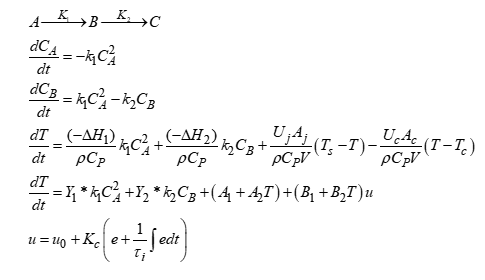

Initialization of Model Parameters :

In [ ]:
Temp0=25.00            #initial temperature
Ca0=1.00               #concentration of species A at start-up, kmol/m3
Cb0=0.00               #concentration of species B at start-up, kmol/m3

A10=1.1                #frequency factor of reaction A -> B,m3/(kmol)(s)
A20=172.2              #frequency factor of reaction B -> C, s–1




Y1=41.8              #Y1=-dH1/dCp
Y2=83.6              #Y2=-dH2/dCp

A1=4.3145            #A1 = (UATsmin+UmaxAT)/(CpV)
A2=-0.10994          #A2 = -(UA+UmaxA)/(CpV)

B1=1.49625           #B1=(UA(Tsmax-Tsmin)-(Umax-Umin)AT)/(CpV)
B2=0.05151           #b2=(Umax-Umin)A/(CpV)
X=2513.8321          #activation energy for reaction A -> B, kJ/kmol
Z=5027.6642          #activation energy for reaction B -> C, kJ/kmol


ER0 =100.00           #Initial error between desired and current temperature
ERINT0=0.0            #Initial value of the integral error expression
U0=1.00               #parametric
Kc=0.1               #PI controller gain
TAUI=360.0           #Integral time constant

t0=0.00              #intital time
dt=0.1               #time width for euler calculation

In [ ]:

Temp_pts= []
Td_pts = []
t_pts = []
Tst_pts = []
Fc_pts = []



t =t0
while t<3600:
  td = 54 + 71*(exp(-0.0025*t))    #Desired (set-point) temperature

  #Start of solving 3 ODE with euler method, Temp -> Reaction temperature, Ca-> concentration of A and Cb-> concentration of B
  Temp =Temp0 + dt*(Y1*A10*exp(-X/(273.00+Temp0))* Ca0*Ca0+(Y2*A20*exp(-Z/(273.00+Temp0))*Cb0)+(A1+A2*Temp0)+((B1+B2*Temp0)*U0))
  Ca = Ca0 - dt*(A10*exp(-X/(273.00+Temp0))*Ca0*Ca0)
  Cb = Cb0 + dt*((A10*exp(-X/(273.00+Temp0))*Ca0*Ca0)-(A20*exp(-Z/(273.00+Temp0))*Cb0))


  #Start of controller part


  ERINT = ERINT0 + dt*ER0
  ER = td - Temp

  U = U0 + Kc*(ER+ERINT/TAUI)                 #Parametric variable
  if U>=1:
    U=1
  if U<=0:
    U=0

  T_st = 80*U+70                               #Steam temperature
  U_c = 4.42 -3.03*U                           #Overall heat transfer coefficient of cooling coil
  F_c_comp = (10.8*U_c)/(4550*(10.8-U_c))
  F_c = pow(F_c_comp,1.25)*100000              #Coolant flow rate

  t_pts.append(t)
  Td_pts.append(td)
  Temp_pts.append(Temp)
  Tst_pts.append(T_st)
  Fc_pts.append(F_c)

  t +=dt
  Temp0 =Temp
  Ca0 = Ca
  Cb0 = Cb
  ER0 = ER
  ERINT0 = ERINT
  U0 = U


Visualization of the results

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_934/3934288799.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Temperature °C or Flowrate m\u00b3/s*$\mathregular{10^{5}}$')


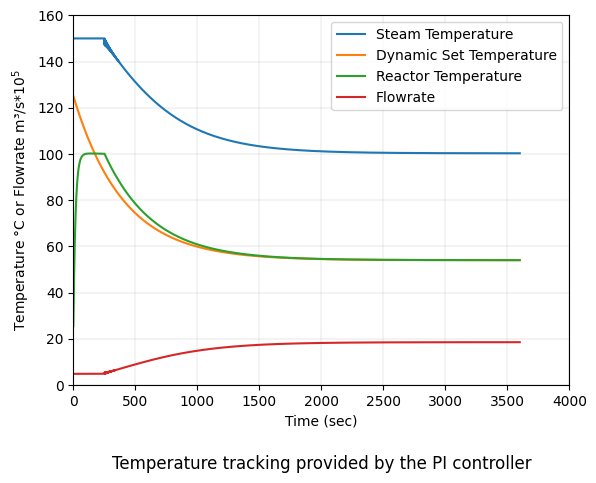

In [ ]:
plt.plot(t_pts,Tst_pts, label ='Steam Temperature')
plt.plot(t_pts,Td_pts, label ='Dynamic Set Temperature')
plt.plot(t_pts,Temp_pts , label ='Reactor Temperature')
plt.plot(t_pts,Fc_pts, label = 'Flowrate')
plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Temperature tracking provided by the PI controller", y=-0.25)
plt.xlabel('Time (sec)')
plt.ylabel('Temperature °C or Flowrate m\u00b3/s*$\mathregular{10^{5}}$')
plt.ylim([0, 160])
plt.xlim([0, 4000])
#plt.yticks(np.arange(0, 170, 10))
plt.grid(True, which='both', linewidth = 0.2)
plt.legend()
plt.show()

Solving the equation with np.zeroes method

In [ ]:
Temp= np.zeros( 36001)
td = np.zeros( 36001)
t_values = np.zeros( 36001)
Tst = np.zeros( 36001)
Fc = np.zeros( 36001)
Ca = np.zeros( 36001)
Cb = np.zeros( 36001)
ER =  np.zeros( 36001)
ERINT = np.zeros( 36001)
U = np.zeros( 36001)

T_st =  np.zeros( 36001)
U_c = np.zeros( 36001)
F_c_comp = np.zeros( 36001)
F_c = np.zeros( 36001)



Temp[0]=25.00
Ca[0]=1.00
Cb[0]=0.00
ER[0] =100.00
ERINT[0]=0.0
U[0]=1.00


for idx, t in enumerate(np.linspace(0, 3600, 36001)):

  td[idx] = 54 + 71*(exp(-0.0025*t))
  Temp[idx] =Temp[idx-1] + dt*(Y1*A10*exp(-X/(273.00+Temp[idx-1]))* Ca[idx-1]*Ca[idx-1]+(Y2*A20*exp(-Z/(273.00+Temp[idx-1]))*Cb[idx-1])
                     +(A1+A2*Temp[idx-1])+((B1+B2*Temp[idx-1])*U[idx-1]))
  Ca[idx] = Ca[idx-1] - dt*(A10*exp(-X/(273.00+Temp[idx-1]))*Ca[idx-1]*Ca[idx-1])
  Cb[idx] = Cb[idx-1] + dt*((A10*exp(-X/(273.00+Temp[idx-1]))*Ca[idx-1]*Ca[idx-1])-(A20*exp(-Z/(273.00+Temp[idx-1]))*Cb[idx-1]))
  ERINT[idx] = ERINT[idx-1] + dt*ER[idx-1]
  ER[idx] = td[idx] - Temp[idx]

  U[idx] = U[idx-1] + Kc*(ER[idx]+ERINT[idx]/TAUI)
  if U[idx]>=1:
    U[idx]=1
  if U[idx]<=0:
    U[idx]=0

  T_st[idx] = 80*U[idx]+70
  U_c[idx] = 4.42 -3.03*U[idx]
  F_c_comp[idx] = (10.8*U_c[idx])/(4550*(10.8-U_c[idx]))
  F_c[idx] = pow(F_c_comp[idx],1.25)*100000

  t_values[idx] = t







Visualization of the results


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_934/3561674545.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Temperature °C or Flowrate m\u00b3/s*$\mathregular{10^{5}}$')


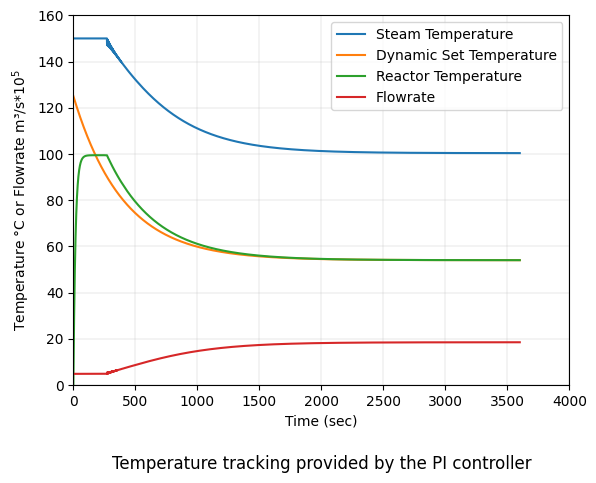

In [ ]:
plt.plot(t_values,T_st, label ='Steam Temperature')
plt.plot(t_values,td , label ='Dynamic Set Temperature')
plt.plot(t_values,Temp , label ='Reactor Temperature')
plt.plot(t_values,F_c, label = 'Flowrate')
plt.axvline(x=0, c="black",linewidth=0.5)
plt.axhline(y=0, c="black",linewidth=0.5)
plt.title("Temperature tracking provided by the PI controller", y=-0.25)
plt.xlabel('Time (sec)')
plt.ylabel('Temperature °C or Flowrate m\u00b3/s*$\mathregular{10^{5}}$')
plt.ylim([0, 160])
plt.xlim([0, 4000])
#plt.yticks(np.arange(0, 170, 10))
plt.grid(True, which='both', linewidth = 0.2)
plt.legend()
plt.show()